# LiH: VQE Optimization with ML Error Mitigation

VQE on LiH (6 qubits) with ideal, noisy, RF-mitigated, and MLP-mitigated cost functions.
Includes 5-run multi-start analysis.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import joblib
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.primitives import StatevectorEstimator
from qiskit import transpile

from qiskit_aer.primitives import Estimator as AerEstimatorV1
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeJakartaV2

print('All imports OK')

All imports OK


## 2. Hamiltonian and Ansatz

In [2]:
import json
with open('lih_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
LIH_COEFFS = meta['hamiltonian_coeffs']
pauli_ops = [SparsePauliOp(p) for p in PAULI_LABELS]
N_QUBITS = meta['n_qubits']

full_op = SparsePauliOp.from_list(list(zip(PAULI_LABELS, LIH_COEFFS)))
E_EXACT = float(np.min(np.linalg.eigvalsh(full_op.to_matrix())))
print(f'Exact ground state energy: {E_EXACT:.6f} Ha')

ansatz = TwoLocal(num_qubits=N_QUBITS, rotation_blocks='ry',
                  entanglement_blocks='cx', entanglement='linear', reps=3)
num_params = ansatz.num_parameters
transpiled_ansatz = transpile(ansatz, basis_gates=['rz', 'sx', 'cx', 'x'], optimization_level=1)
print(f'Ansatz: {num_params} parameters, depth {transpiled_ansatz.depth()}')

backend = FakeJakartaV2()
noise_model = NoiseModel.from_backend(backend)
ideal_estimator = StatevectorEstimator()
noisy_estimator = AerEstimatorV1()
noisy_estimator.set_options(noise_model=noise_model, shots=10000)
print('Estimators ready.')

Exact ground state energy: -1.060104 Ha
Ansatz: 24 parameters, depth 25
Estimators ready.


## 3. Load RF, Train MLP, Define Cost Functions

In [3]:
rf = joblib.load('lih_rf_mlqem.joblib')
print(f'RF loaded: {rf.n_estimators} trees, {rf.n_features_in_} features')

N_2Q = meta['n_2q_gates']; N_SX = meta['n_sx_gates']
props = backend.properties()
QUBIT_NOISE = {}
for q in range(N_QUBITS):
    QUBIT_NOISE[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

PAULI_ENCODINGS = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
                   for label in PAULI_LABELS}

def build_correction_features(noisy_val, pauli_label):
    symp = PAULI_ENCODINGS[pauli_label]
    feats = [noisy_val, *symp, N_2Q, N_SX]
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([QUBIT_NOISE[q]['T1']*active, QUBIT_NOISE[q]['T2']*active,
                      QUBIT_NOISE[q]['readout_error']*active])
    return feats

# ── Train MLP ──
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)

ideal_data = np.load('lih_ideal_data.npy')
noisy_data = np.load('lih_noisy_data.npy')
ALL_OBS = list(range(1, len(PAULI_LABELS)))

X_train_rows, y_train_rows = [], []
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    for i in range(1800):
        X_train_rows.append(build_correction_features(noisy_data[i, obs_idx], label))
        y_train_rows.append(ideal_data[i, obs_idx])
X_train_mlp = np.array(X_train_rows, dtype=np.float32)
y_train_mlp = np.array(y_train_rows, dtype=np.float32)

n_val = int(0.2 * len(X_train_mlp))
idx_perm = np.random.RandomState(42).permutation(len(X_train_mlp))
val_idx, train_idx = idx_perm[:n_val], idx_perm[n_val:]

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_mlp[train_idx])
X_val_sc = scaler.transform(X_train_mlp[val_idx])

Xt = torch.tensor(X_tr_sc, dtype=torch.float32)
yt = torch.tensor(y_train_mlp[train_idx], dtype=torch.float32).unsqueeze(1)
Xv = torch.tensor(X_val_sc, dtype=torch.float32)

torch.manual_seed(2)
mlp_model = MLP(X_train_mlp.shape[1])
opt = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.HuberLoss()

best_val, best_state, no_imp = float('inf'), None, 0
for epoch in range(2000):
    mlp_model.train(); opt.zero_grad(); crit(mlp_model(Xt), yt).backward(); opt.step()
    mlp_model.eval()
    with torch.no_grad():
        vm = mean_absolute_error(y_train_mlp[val_idx], mlp_model(Xv).numpy().ravel())
    if vm < best_val - 1e-6:
        best_val = vm; best_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}; no_imp = 0
    else: no_imp += 1
    if no_imp >= 25: break
mlp_model.load_state_dict(best_state); mlp_model.eval()
print(f'MLP trained (stopped at epoch {epoch+1})')

# ── Cost functions ──
def ideal_cost(theta):
    bound = transpiled_ansatz.assign_parameters(theta)
    job = ideal_estimator.run([(bound, op) for op in pauli_ops])
    result = job.result()
    return sum(c * result[j].data.evs for j, c in enumerate(LIH_COEFFS))

def noisy_cost(theta):
    bound = transpiled_ansatz.assign_parameters(theta)
    job = noisy_estimator.run([bound] * len(pauli_ops), pauli_ops)
    result = job.result()
    return sum(c * v for c, v in zip(LIH_COEFFS, result.values))

def mitigated_cost(theta):
    bound = transpiled_ansatz.assign_parameters(theta)
    job = noisy_estimator.run([bound] * len(pauli_ops), pauli_ops)
    result = job.result()
    corrected = []
    for j, (label, val) in enumerate(zip(PAULI_LABELS, result.values)):
        if j == 0: corrected.append(1.0)
        else: corrected.append(rf.predict([build_correction_features(val, label)])[0])
    return sum(c * v for c, v in zip(LIH_COEFFS, corrected))

def mlp_mitigated_cost(theta):
    bound = transpiled_ansatz.assign_parameters(theta)
    job = noisy_estimator.run([bound] * len(pauli_ops), pauli_ops)
    result = job.result()
    corrected = []
    for j, (label, val) in enumerate(zip(PAULI_LABELS, result.values)):
        if j == 0: corrected.append(1.0)
        else:
            feats = np.array([build_correction_features(val, label)], dtype=np.float32)
            feats_sc = scaler.transform(feats)
            with torch.no_grad():
                corrected.append(mlp_model(torch.tensor(feats_sc)).item())
    return sum(c * v for c, v in zip(LIH_COEFFS, corrected))

print('Cost functions defined.')

RF loaded: 100 trees, 33 features
MLP trained (stopped at epoch 1189)
Cost functions defined.


## 4. Run VQE (single run)

In [6]:
MAXITER = 1000
np.random.seed(42)
theta0 = np.random.randn(num_params) * 0.1

def run_vqe(cost_fn, label, theta_init=None, maxiter=MAXITER):
    if theta_init is None: theta_init = theta0
    history = []
    def tracked(theta):
        e = cost_fn(theta); history.append(e)
        if len(history) % 25 == 0: print(f'    [{label}] iter {len(history):>3}: E = {e:.6f}')
        return e
    print(f'  Starting {label} VQE...')
    result = minimize(tracked, theta_init.copy(), method='COBYLA', options={'maxiter': maxiter, 'rhobeg': 0.5})
    print(f'  {label} done: E = {result.fun:.6f} ({len(history)} evals)')
    return result.fun, result.x, history

E_ideal, theta_ideal, hist_ideal = run_vqe(ideal_cost, 'Ideal'); print()
E_noisy, theta_noisy, hist_noisy = run_vqe(noisy_cost, 'Noisy'); print()
E_mitig, theta_mitig, hist_mitig = run_vqe(mitigated_cost, 'RF-mitigated'); print()
E_mlp_mit, theta_mlp, hist_mlp = run_vqe(mlp_mitigated_cost, 'MLP-mitigated')

print(f'\nExact GS:         {E_EXACT:.6f} Ha')
print(f'Ideal VQE:        {E_ideal:.6f} Ha  (error: {abs(E_ideal - E_EXACT):.6f})')
print(f'Noisy VQE:        {E_noisy:.6f} Ha  (error: {abs(E_noisy - E_EXACT):.6f})')
print(f'RF-mitigated:     {E_mitig:.6f} Ha  (error: {abs(E_mitig - E_EXACT):.6f})')
print(f'MLP-mitigated:    {E_mlp_mit:.6f} Ha  (error: {abs(E_mlp_mit - E_EXACT):.6f})')

  Starting Ideal VQE...
    [Ideal] iter  25: E = -0.519531
    [Ideal] iter  50: E = -0.788281
    [Ideal] iter  75: E = -0.870276
    [Ideal] iter 100: E = -0.969788
    [Ideal] iter 125: E = -0.994552
    [Ideal] iter 150: E = -1.010639
    [Ideal] iter 175: E = -1.041118
    [Ideal] iter 200: E = -1.052376
    [Ideal] iter 225: E = -1.055014
    [Ideal] iter 250: E = -1.057455
    [Ideal] iter 275: E = -1.058563
    [Ideal] iter 300: E = -1.058747
    [Ideal] iter 325: E = -1.058977
    [Ideal] iter 350: E = -1.059083
    [Ideal] iter 375: E = -1.059115
    [Ideal] iter 400: E = -1.059157
    [Ideal] iter 425: E = -1.059180
    [Ideal] iter 450: E = -1.059176
    [Ideal] iter 475: E = -1.059205
    [Ideal] iter 500: E = -1.059216
    [Ideal] iter 525: E = -1.059232
    [Ideal] iter 550: E = -1.059232
    [Ideal] iter 575: E = -1.059241
    [Ideal] iter 600: E = -1.059243
    [Ideal] iter 625: E = -1.059246
    [Ideal] iter 650: E = -1.059245
    [Ideal] iter 675: E = -1.059252
    

## 5. Evaluate at θ* (20 times)

In [7]:
N_EVAL = 20
print(f'Evaluating {N_EVAL} times at ideal θ*...\n')
ideal_at_opt = ideal_cost(theta_ideal)
noisy_evals = [noisy_cost(theta_ideal) for _ in range(N_EVAL)]
rf_evals = [mitigated_cost(theta_ideal) for _ in range(N_EVAL)]
mlp_evals = [mlp_mitigated_cost(theta_ideal) for _ in range(N_EVAL)]

print(f'At ideal θ*:')
print(f'  Exact:        {E_EXACT:.6f} Ha')
print(f'  Ideal VQE:    {ideal_at_opt:.6f} Ha')
print(f'  Noisy:        {np.mean(noisy_evals):.6f} ± {np.std(noisy_evals):.4f}  (bias: {np.mean(noisy_evals)-E_EXACT:+.4f})')
print(f'  RF-mitigated: {np.mean(rf_evals):.6f} ± {np.std(rf_evals):.4f}  (bias: {np.mean(rf_evals)-E_EXACT:+.4f})')
print(f'  MLP-mitigated:{np.mean(mlp_evals):.6f} ± {np.std(mlp_evals):.4f}  (bias: {np.mean(mlp_evals)-E_EXACT:+.4f})')
print(f'\nBias reduction (RF):  {abs(np.mean(noisy_evals)-E_EXACT)/abs(np.mean(rf_evals)-E_EXACT):.1f}x')
print(f'Bias reduction (MLP): {abs(np.mean(noisy_evals)-E_EXACT)/abs(np.mean(mlp_evals)-E_EXACT):.1f}x')

Evaluating 20 times at ideal θ*...

At ideal θ*:
  Exact:        -1.060104 Ha
  Ideal VQE:    -1.059265 Ha
  Noisy:        -1.005912 ± 0.0013  (bias: +0.0542)
  RF-mitigated: -1.038697 ± 0.0021  (bias: +0.0214)
  MLP-mitigated:-1.074871 ± 0.0020  (bias: -0.0148)

Bias reduction (RF):  2.5x
Bias reduction (MLP): 3.7x


## 6. Multi-Run VQE (5 initial points)

In [8]:
N_RUNS = 5
print(f'Running {N_RUNS} VQE optimizations from different initial points...\n')
multi_results = {'ideal': [], 'noisy': [], 'rf': [], 'mlp': []}
multi_histories = {'ideal': [], 'noisy': [], 'rf': [], 'mlp': []}

for run in range(N_RUNS):
    rng_run = np.random.RandomState(run + 100)
    theta0_run = rng_run.randn(num_params) * 0.1
    print(f'--- Run {run + 1}/{N_RUNS} ---')
    for cost_fn, label, key in [(ideal_cost, f'Ideal-{run+1}', 'ideal'),
                                 (noisy_cost, f'Noisy-{run+1}', 'noisy'),
                                 (mitigated_cost, f'RF-{run+1}', 'rf'),
                                 (mlp_mitigated_cost, f'MLP-{run+1}', 'mlp')]:
        history = []
        def tracked(theta, hist=history):
            e = cost_fn(theta); hist.append(e); return e
        result = minimize(tracked, theta0_run.copy(), method='COBYLA', options={'maxiter': 1000, 'rhobeg': 0.5})
        multi_results[key].append(result.fun)
        multi_histories[key].append(history)
        print(f'  {label}: E = {result.fun:.6f} (error: {abs(result.fun - E_EXACT):.4f})')
    print()

print('=' * 65)
print(f'{"Method":<20} {"Mean E (Ha)":>14} {"Std":>10} {"Mean |error| (mHa)":>20}')
print('-' * 65)
for key, label in [('ideal', 'Ideal'), ('noisy', 'Noisy'), ('rf', 'RF-mitigated'), ('mlp', 'MLP-mitigated')]:
    energies = np.array(multi_results[key])
    errors = np.abs(energies - E_EXACT)
    print(f'{label:<20} {energies.mean():>14.6f} {energies.std():>10.4f} {errors.mean()*1000:>16.2f} mHa')
print(f'\nChemical accuracy: 1.6 mHa')
for key, label in [('rf', 'RF'), ('mlp', 'MLP')]:
    errs = np.abs(np.array(multi_results[key]) - E_EXACT)
    print(f'{label} runs within chem. acc.: {np.sum(errs < 0.0016)}/{N_RUNS}')

Running 5 VQE optimizations from different initial points...

--- Run 1/5 ---
  Ideal-1: E = -1.059249 (error: 0.0009)
  Noisy-1: E = -0.865516 (error: 0.1946)
  RF-1: E = -0.870906 (error: 0.1892)
  MLP-1: E = -0.935704 (error: 0.1244)

--- Run 2/5 ---
  Ideal-2: E = -1.059053 (error: 0.0011)
  Noisy-2: E = -1.000333 (error: 0.0598)
  RF-2: E = -0.924333 (error: 0.1358)
  MLP-2: E = -1.005992 (error: 0.0541)

--- Run 3/5 ---
  Ideal-3: E = -1.058924 (error: 0.0012)
  Noisy-3: E = -0.851841 (error: 0.2083)
  RF-3: E = -0.888534 (error: 0.1716)
  MLP-3: E = -0.997115 (error: 0.0630)

--- Run 4/5 ---
  Ideal-4: E = -1.059151 (error: 0.0010)
  Noisy-4: E = -0.840447 (error: 0.2197)
  RF-4: E = -0.877581 (error: 0.1825)
  MLP-4: E = -1.030637 (error: 0.0295)

--- Run 5/5 ---
  Ideal-5: E = -1.059249 (error: 0.0009)
  Noisy-5: E = -0.996736 (error: 0.0634)
  RF-5: E = -0.989367 (error: 0.0707)
  MLP-5: E = -0.997400 (error: 0.0627)

Method                  Mean E (Ha)        Std   Mean |err

## 7. Multi-Run Convergence Plot

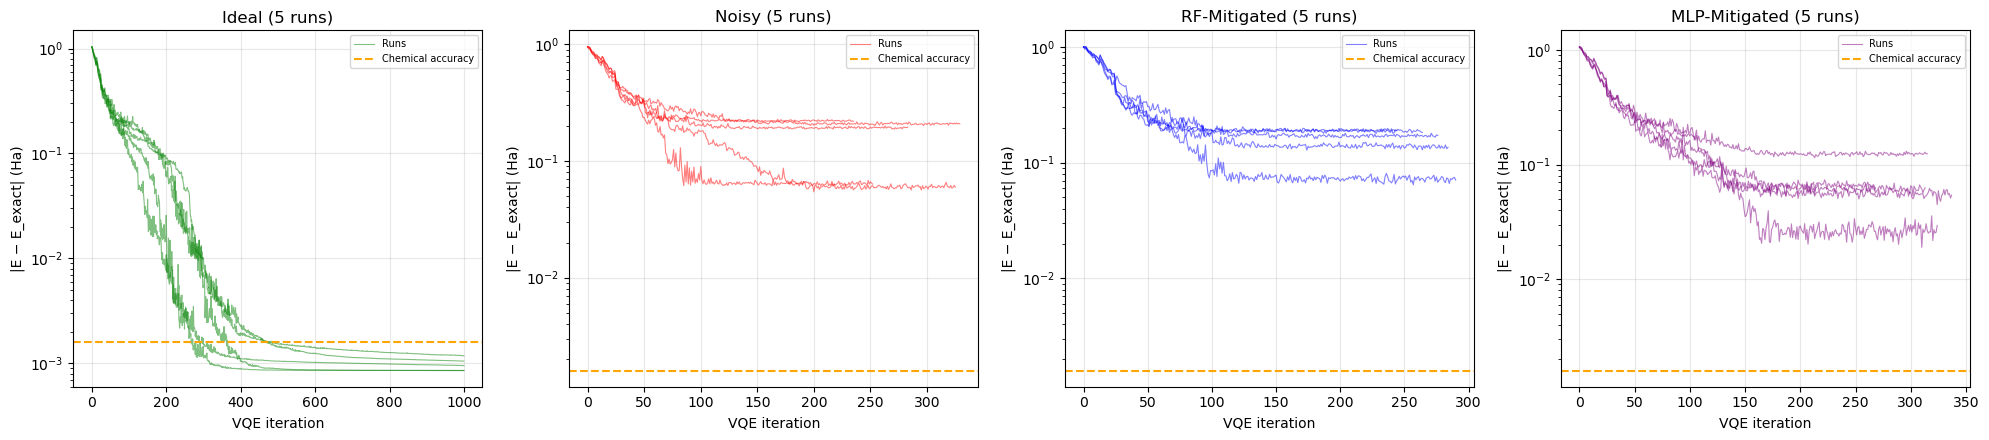

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, key, label, color in [(axes[0], 'ideal', 'Ideal', 'green'),
                               (axes[1], 'noisy', 'Noisy', 'red'),
                               (axes[2], 'rf', 'RF-Mitigated', 'blue'),
                               (axes[3], 'mlp', 'MLP-Mitigated', 'purple')]:
    for i, hist in enumerate(multi_histories[key]):
        errors = np.abs(np.array(hist) - E_EXACT)
        ax.plot(errors, color=color, alpha=0.5, linewidth=0.8, label='Runs' if i == 0 else None)
    ax.axhline(0.0016, color='orange', linestyle='--', linewidth=1.5, label='Chemical accuracy')
    ax.set_yscale('log'); ax.set_xlabel('VQE iteration'); ax.set_ylabel('|E − E_exact| (Ha)')
    ax.set_title(f'{label} ({N_RUNS} runs)'); ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('lih_vqe_multi_run.png', dpi=150, bbox_inches='tight')
plt.show()